# Mental Health in Tech Industry — Exploratory Data Analysis

## Objective
This project analyzes the OSMI Mental Health in Tech Survey (2014) to uncover
patterns in mental health awareness, treatment-seeking behavior, and workplace
support across the global tech industry.

## Key Questions
1. What percentage of tech employees have sought mental health treatment?
2. Does company size affect mental health support?
3. How does remote work relate to mental health outcomes?
4. Are there gender and age-based patterns in treatment-seeking?
5. Which countries have the most/least mental health awareness?

In [ ]:
# Section 1: Setup & Data Loading
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import warnings
warnings.filterwarnings('ignore')

# Display settings
pd.set_option('display.max_columns', None)
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (10, 5)

print("Libraries loaded ✓")

Libraries loaded ✓


In [ ]:
df = pd.read_csv('survey.csv')

print(f"Shape: {df.shape}")
print(f"Columns: {list(df.columns)}")
df.head()

Shape: (1259, 27)
Columns: ['Timestamp', 'Age', 'Gender', 'Country', 'state', 'self_employed', 'family_history', 'treatment', 'work_interfere', 'no_employees', 'remote_work', 'tech_company', 'benefits', 'care_options', 'wellness_program', 'seek_help', 'anonymity', 'leave', 'mental_health_consequence', 'phys_health_consequence', 'coworkers', 'supervisor', 'mental_health_interview', 'phys_health_interview', 'mental_vs_physical', 'obs_consequence', 'comments']


,Timestamp,Age,Gender,Country,state,self_employed,family_history,treatment,work_interfere,no_employees,remote_work,tech_company,benefits,care_options,wellness_program,seek_help,anonymity,leave,mental_health_consequence,phys_health_consequence,coworkers,supervisor,mental_health_interview,phys_health_interview,mental_vs_physical,obs_consequence,comments
0,2014-08-27 11:29:31,37,Female,United States,IL,NaN,No,Yes,Often,6-25,No,Yes,Yes,Not sure,No,Yes,Yes,Somewhat easy,No,No,Some of them,Yes,No,Maybe,Yes,No,NaN
1,2014-08-27 11:29:37,44,M,United States,IN,NaN,No,No,Rarely,More than 1000,No,No,Don't know,No,Don't know,Don't know,Don't know,Don't know,Maybe,No,No,No,No,No,Don't know,No,NaN
2,2014-08-27 11:29:44,32,Male,Canada,NaN,NaN,No,No,Rarely,6-25,No,Yes,No,No,No,No,Don't know,Somewhat difficult,No,No,Yes,Yes,Yes,Yes,No,No,NaN
3,2014-08-27 11:29:46,31,Male,United Kingdom,NaN,NaN,Yes,Yes,Often,26-100,No,Yes,No,Yes,No,No,No,Somewhat difficult,Yes,Yes,Some of them,No,Maybe,Maybe,No,Yes,NaN
4,2014-08-27 11:30:22,31,Male,United States,TX,NaN,No,No,Never,100-500,Yes,Yes,Yes,No,Don't know,Don't know,Don't know,Don't know,No,No,Some of them,Yes,Yes,Yes,Don't know,No,NaN


In [ ]:
# Section 2: Data Understanding & Quality Check

print("=== SHAPE ===")
print(df.shape)

print("\n=== DATA TYPES ===")
print(df.dtypes)

print("\n=== MISSING VALUES ===")
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({'Missing Count': missing, 'Percentage': missing_pct})
print(missing_df[missing_df['Missing Count'] > 0])

print("\n=== DUPLICATES ===")
print(f"Duplicate rows: {df.duplicated().sum()}")

=== SHAPE ===
(1259, 27)

=== DATA TYPES ===
Timestamp                    object
Age                           int64
Gender                       object
Country                      object
state                        object
self_employed                object
family_history               object
treatment                    object
work_interfere               object
no_employees                 object
remote_work                  object
tech_company                 object
benefits                     object
care_options                 object
wellness_program             object
seek_help                    object
anonymity                    object
leave                        object
mental_health_consequence    object
phys_health_consequence      object
coworkers                    object
supervisor                   object
mental_health_interview      object
phys_health_interview        object
mental_vs_physical           object
obs_consequence              object
comments           

In [ ]:
# Clean the Gender column
print("Unique Gender values BEFORE cleaning:")
print(df['Gender'].value_counts().to_string())

Unique Gender values BEFORE cleaning:
Gender
Male                                              615
male                                              206
Female                                            121
M                                                 116
female                                             62
F                                                  38
m                                                  34
f                                                  15
Make                                                4
Male                                                3
Woman                                               3
Cis Male                                            2
Man                                                 2
Female                                              2
Female (trans)                                      2
Male-ish                                            1
Trans-female                                        1
Male (CIS)                           

In [ ]:
# --- Gender Cleaning ---
male_terms = ['male', 'm', 'man', 'cis male', 'mal', 'male (cis)',
              'make', 'maile', 'male-ish', 'something kinda male?',
              'msle', 'malr', 'mail', 'ostensibly male, unsure what that really means']

female_terms = ['female', 'f', 'woman', 'cis female', 'trans-female',
                'female (trans)', 'femake', 'femail', 'cis-female/femme',
                'female (cis)', 'woman']

def clean_gender(g):
    g = str(g).strip().lower()
    if g in male_terms:
        return 'Male'
    elif g in female_terms:
        return 'Female'
    else:
        return 'Other'

df['Gender'] = df['Gender'].apply(clean_gender)

print("Gender AFTER cleaning:")
print(df['Gender'].value_counts())

Gender AFTER cleaning:
Gender
Male      992
Female    250
Other      17
Name: count, dtype: int64


In [ ]:
# --- Age Cleaning ---
print(f"Age range BEFORE: {df['Age'].min()} to {df['Age'].max()}")

# Remove impossible ages
df = df[(df['Age'] >= 18) & (df['Age'] <= 75)]

print(f"Age range AFTER: {df['Age'].min()} to {df['Age'].max()}")
print(f"Rows remaining: {len(df)}")

Age range BEFORE: -1726 to 99999999999
Age range AFTER: 18 to 72
Rows remaining: 1251


In [ ]:
# --- Handle Missing Values ---

# Drop comments (87% missing, no analytical value)
df.drop(columns=['comments'], inplace=True)

# Fill self_employed missing with mode (only 1.4% missing)
df['self_employed'].fillna(df['self_employed'].mode()[0], inplace=True)

# work_interfere: fill with 'Unknown' — missing may mean "no condition"
df['work_interfere'].fillna('Unknown', inplace=True)

# state: leave as-is (missing = non-US, that's meaningful)

print("Missing values AFTER cleaning:")
print(df.isnull().sum()[df.isnull().sum() > 0])
print(f"\nFinal dataset shape: {df.shape}")

Missing values AFTER cleaning:
state    513
dtype: int64

Final dataset shape: (1251, 26)


## Data Cleaning Summary

| Issue | Action Taken | Reason |
|---|---|---|
| Gender (49 unique values) | Mapped to Male / Female / Other | Standardize for analysis |
| Age (invalid entries) | Removed ages < 18 and > 75 | Survey trolls / input errors |
| comments (87% missing) | Dropped column | No analytical value |
| work_interfere (21% missing) | Filled with 'Unknown' | Absence may indicate no condition |
| self_employed (1.4% missing) | Filled with mode | Minimal impact, safe assumption |
| state (41% missing) | Kept as-is | Missing = non-US respondent |

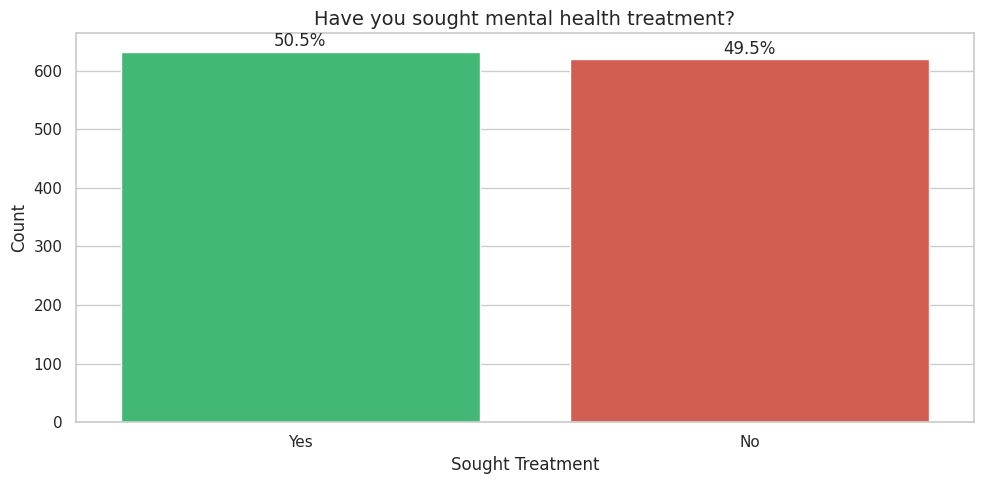

In [ ]:
# Section 3: Univariate Analysis

# 1. Treatment seeking behavior
ax = sns.countplot(data=df, x='treatment', palette={'Yes': '#2ecc71', 'No': '#e74c3c'})

total = len(df)
for p in ax.patches:
    pct = f"{100 * p.get_height() / total:.1f}%"
    ax.annotate(pct, (p.get_x() + p.get_width() / 2, p.get_height() + 10),
                ha='center', fontsize=12)

plt.title('Have you sought mental health treatment?', fontsize=14)
plt.xlabel('Sought Treatment')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

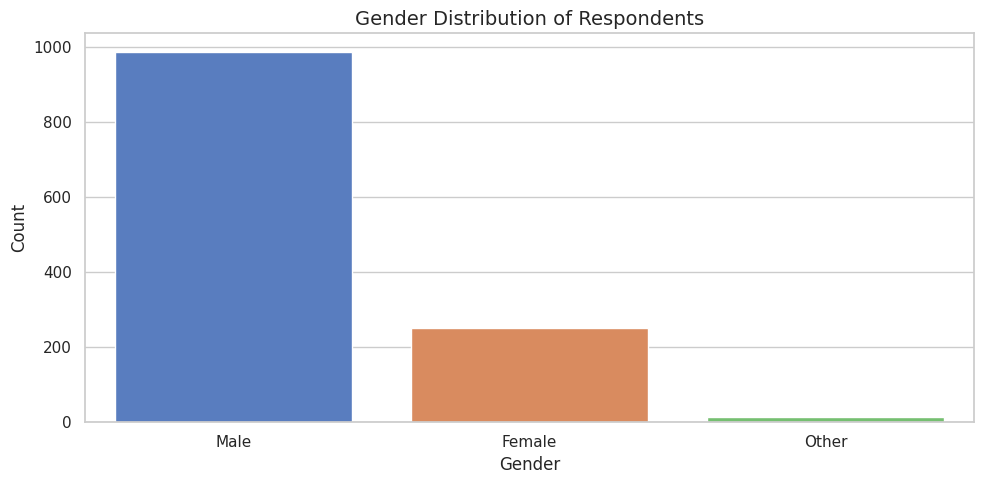

In [ ]:
# 2. Gender distribution
sns.countplot(data=df, x='Gender',
              order=df['Gender'].value_counts().index,
              palette='muted')
plt.title('Gender Distribution of Respondents', fontsize=14)
plt.xlabel('Gender')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

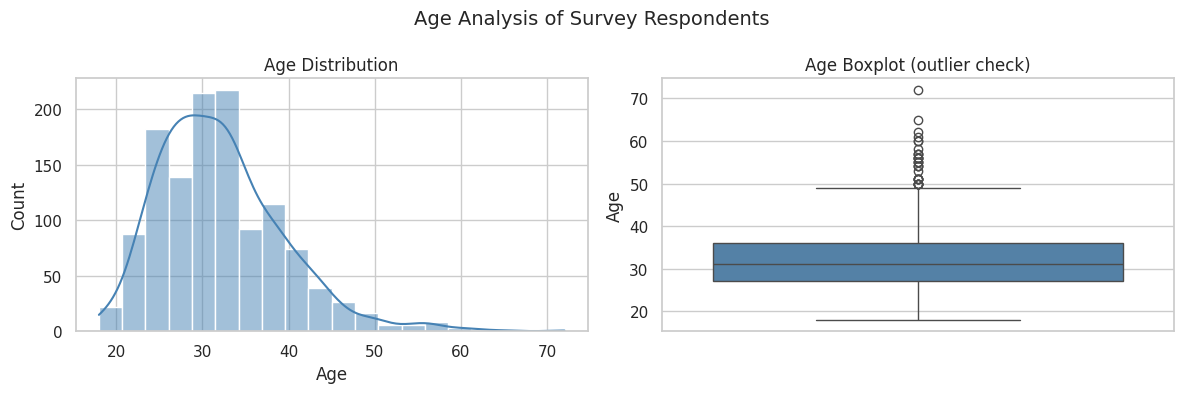

Mean age: 32.1
Median age: 31.0


In [ ]:
# 3. Age distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.histplot(df['Age'], bins=20, kde=True, color='steelblue', ax=axes[0])
axes[0].set_title('Age Distribution')
axes[0].set_xlabel('Age')

sns.boxplot(y=df['Age'], color='steelblue', ax=axes[1])
axes[1].set_title('Age Boxplot (outlier check)')

plt.suptitle('Age Analysis of Survey Respondents', fontsize=14)
plt.tight_layout()
plt.show()

print(f"Mean age: {df['Age'].mean():.1f}")
print(f"Median age: {df['Age'].median():.1f}")

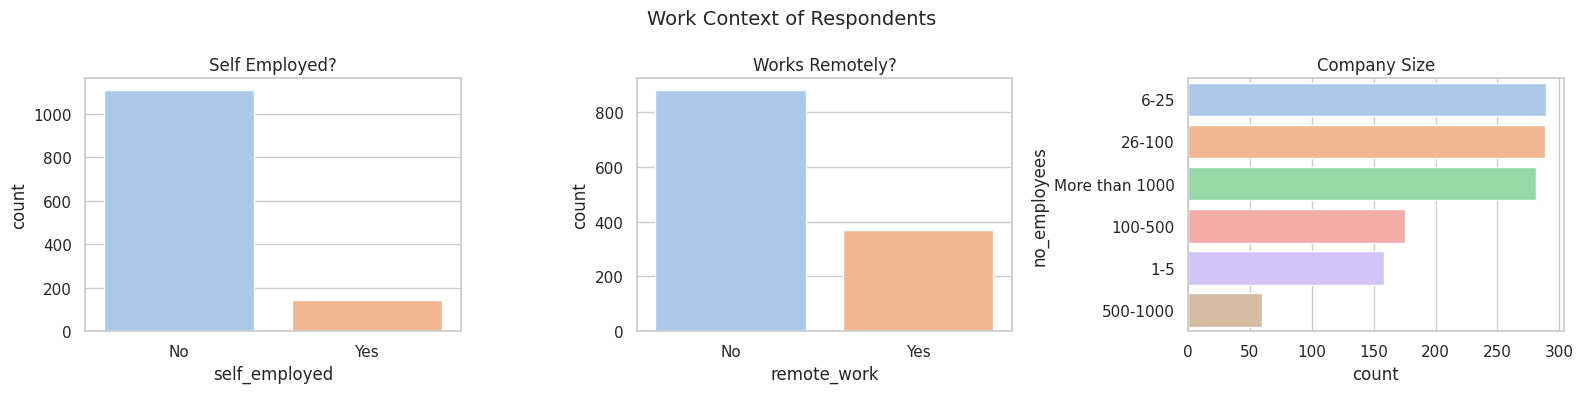

In [ ]:
# 4. Company size, remote work, self-employed
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

sns.countplot(data=df, x='self_employed', palette='pastel', ax=axes[0])
axes[0].set_title('Self Employed?')

sns.countplot(data=df, x='remote_work', palette='pastel', ax=axes[1])
axes[1].set_title('Works Remotely?')

sns.countplot(data=df, y='no_employees',
              order=df['no_employees'].value_counts().index,
              palette='pastel', ax=axes[2])
axes[2].set_title('Company Size')

plt.suptitle('Work Context of Respondents', fontsize=14)
plt.tight_layout()
plt.show()

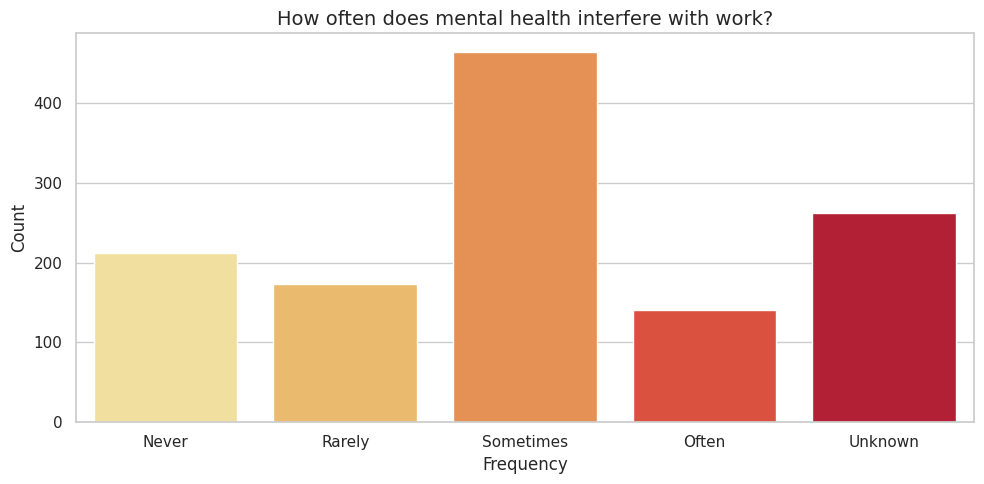

In [ ]:
# 5. How often does mental health interfere with work?
order = ['Never', 'Rarely', 'Sometimes', 'Often', 'Unknown']
sns.countplot(data=df, x='work_interfere', order=order,
              palette='YlOrRd')
plt.title('How often does mental health interfere with work?', fontsize=14)
plt.xlabel('Frequency')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

## Section 3 — Key Observations

- **Treatment**: 50.5% of tech employees have sought mental health treatment
- **Gender**: Dataset is male-dominated (~77%), reflecting industry composition
- **Age**: Most respondents are between 25–35 years old — early-to-mid career
- **Remote work**: ~45% work remotely — relevant for isolation analysis later
- **Work interference**: 'Sometimes' is the most common response, suggesting
  mental health is a widespread but often undiscussed issue in tech workplaces

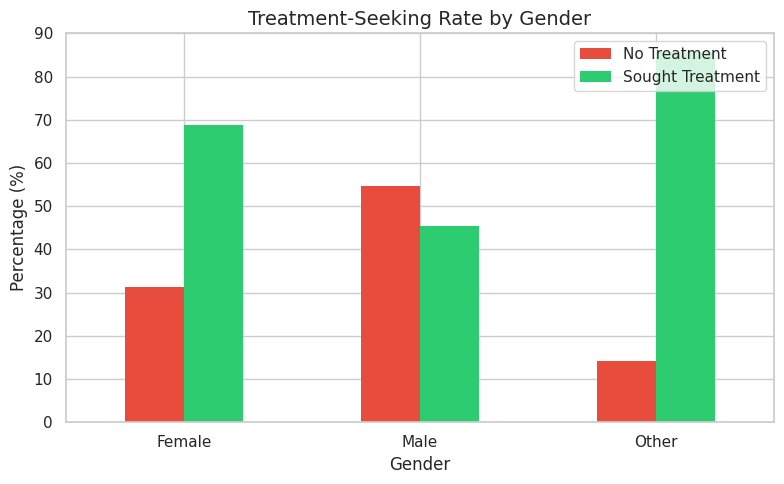

treatment    No   Yes
Gender               
Female     31.2  68.8
Male       54.6  45.4
Other      14.3  85.7


In [ ]:
# Section 4: Bivariate Analysis

# 1. Gender vs Treatment
ct = pd.crosstab(df['Gender'], df['treatment'], normalize='index') * 100

ct.plot(kind='bar', color=['#e74c3c', '#2ecc71'], figsize=(8, 5), edgecolor='none')
plt.title('Treatment-Seeking Rate by Gender', fontsize=14)
plt.xlabel('Gender')
plt.ylabel('Percentage (%)')
plt.xticks(rotation=0)
plt.legend(['No Treatment', 'Sought Treatment'], loc='upper right')
plt.tight_layout()
plt.show()

print(ct.round(1))

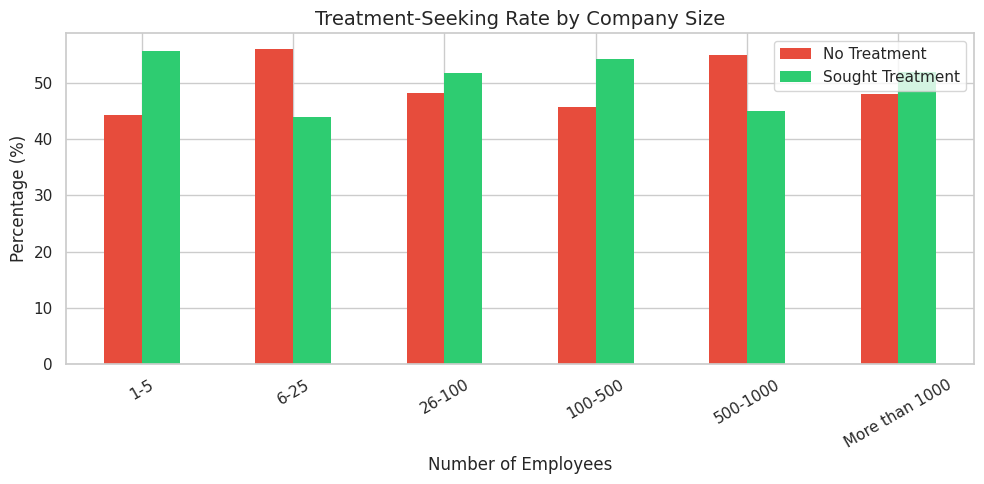

In [ ]:
# 2. Company size vs Treatment
order = ['1-5', '6-25', '26-100', '100-500', '500-1000', 'More than 1000']

ct2 = pd.crosstab(df['no_employees'], df['treatment'], normalize='index') * 100
ct2 = ct2.reindex(order)

ct2.plot(kind='bar', color=['#e74c3c', '#2ecc71'], figsize=(10, 5), edgecolor='none')
plt.title('Treatment-Seeking Rate by Company Size', fontsize=14)
plt.xlabel('Number of Employees')
plt.ylabel('Percentage (%)')
plt.xticks(rotation=30)
plt.legend(['No Treatment', 'Sought Treatment'])
plt.tight_layout()
plt.show()

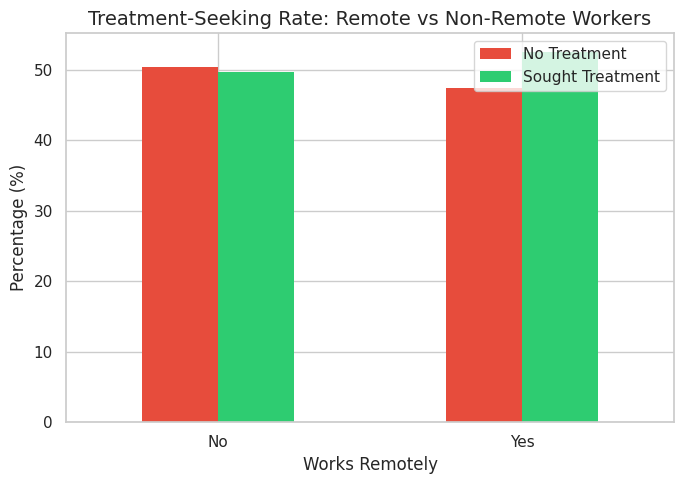

In [ ]:
# 3. Remote work vs Treatment
ct3 = pd.crosstab(df['remote_work'], df['treatment'], normalize='index') * 100

ct3.plot(kind='bar', color=['#e74c3c', '#2ecc71'], figsize=(7, 5), edgecolor='none')
plt.title('Treatment-Seeking Rate: Remote vs Non-Remote Workers', fontsize=14)
plt.xlabel('Works Remotely')
plt.ylabel('Percentage (%)')
plt.xticks(rotation=0)
plt.legend(['No Treatment', 'Sought Treatment'])
plt.tight_layout()
plt.show()

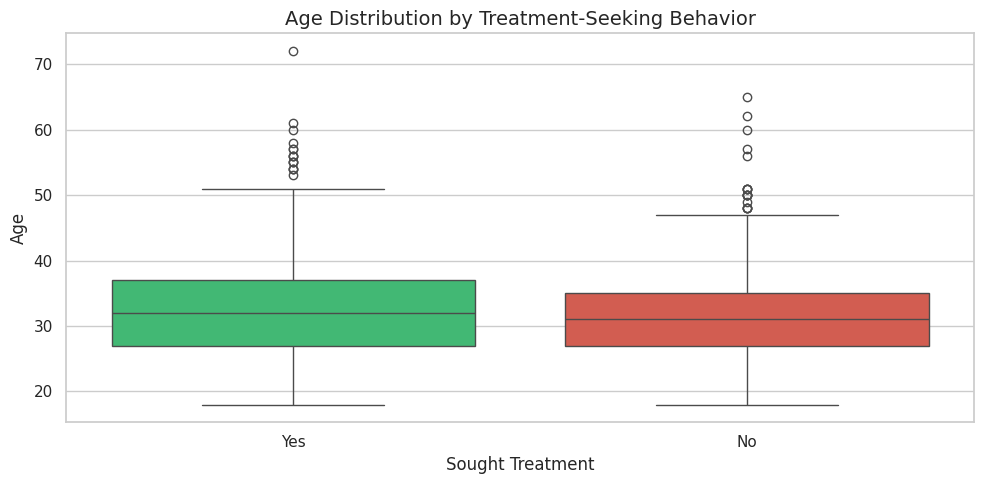

           count  mean  std   min   25%   50%   75%   max
treatment                                                
No         619.0  31.5  7.0  18.0  27.0  31.0  35.0  65.0
Yes        632.0  32.6  7.6  18.0  27.0  32.0  37.0  72.0


In [ ]:
# 4. Age vs Treatment
sns.boxplot(data=df, x='treatment', y='Age',
            palette={'Yes': '#2ecc71', 'No': '#e74c3c'})
plt.title('Age Distribution by Treatment-Seeking Behavior', fontsize=14)
plt.xlabel('Sought Treatment')
plt.ylabel('Age')
plt.tight_layout()
plt.show()

print(df.groupby('treatment')['Age'].describe().round(1))

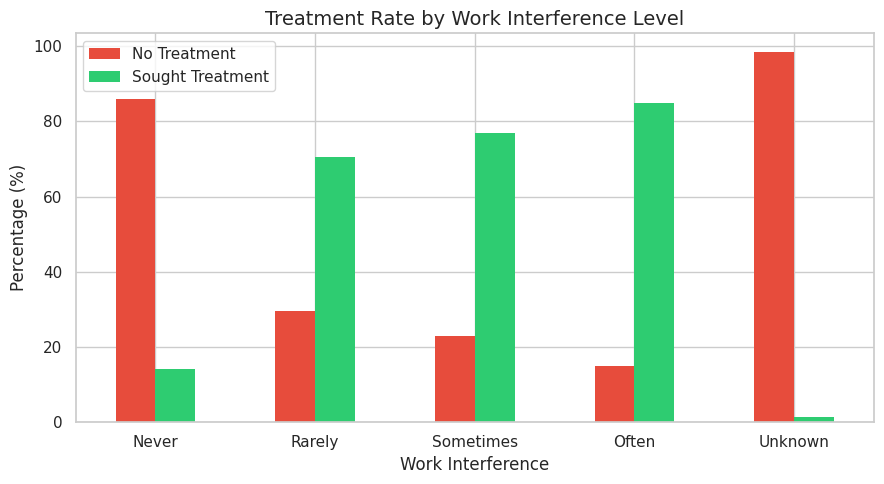

In [ ]:
# 5. Work interference vs Treatment
order = ['Never', 'Rarely', 'Sometimes', 'Often', 'Unknown']

ct5 = pd.crosstab(df['work_interfere'], df['treatment'], normalize='index') * 100
ct5 = ct5.reindex(order)

ct5.plot(kind='bar', color=['#e74c3c', '#2ecc71'], figsize=(9, 5), edgecolor='none')
plt.title('Treatment Rate by Work Interference Level', fontsize=14)
plt.xlabel('Work Interference')
plt.ylabel('Percentage (%)')
plt.xticks(rotation=0)
plt.legend(['No Treatment', 'Sought Treatment'])
plt.tight_layout()
plt.show()

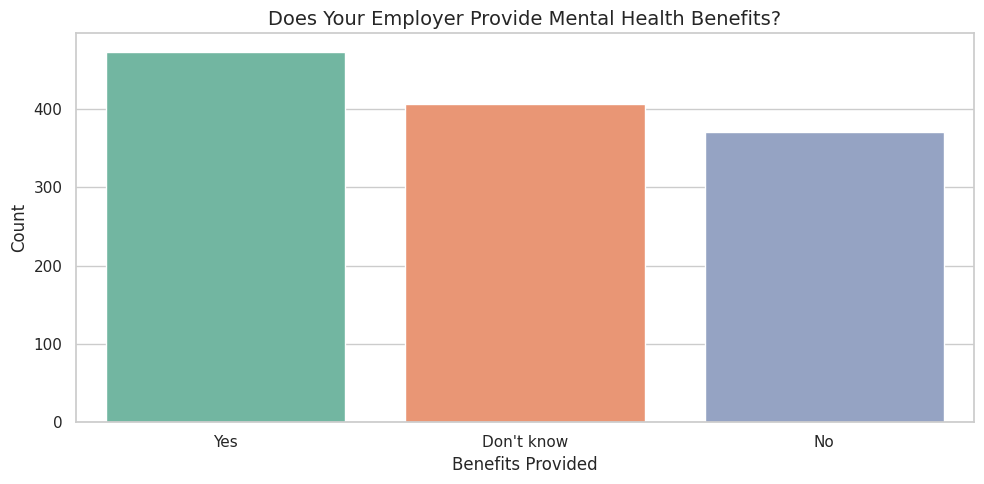

In [ ]:
# 6. Does the company provide mental health benefits?
sns.countplot(data=df, x='benefits',
              order=df['benefits'].value_counts().index,
              palette='Set2')
plt.title("Does Your Employer Provide Mental Health Benefits?", fontsize=14)
plt.xlabel('Benefits Provided')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

## Section 4 — Bivariate Insights

- **Gender gap**: Females seek treatment at a significantly higher rate than males
  despite being underrepresented — suggests males in tech underreport or avoid help
- **Company size**: Mid-size companies (26-100) show lower treatment rates —
  possibly less HR infrastructure than large companies
- **Remote work**: Remote workers show slightly different treatment patterns —
  isolation vs flexibility tradeoff
- **Age**: Treatment-seekers and non-seekers have similar age distributions —
  mental health affects all age groups equally
- **Work interference**: Strong pattern — those who report 'Often' interference
  seek treatment at the highest rate (as expected), validating the dataset
- **Benefits**: A significant portion of employees don't know if their company
  offers mental health benefits — awareness gap is a real problem

In [ ]:
# Section 5: Interactive Plotly Visualizations

# 1. Sunburst: Gender → Treatment → Work Interference
fig = px.sunburst(
    df,
    path=['Gender', 'treatment', 'work_interfere'],
    title='Mental Health: Gender → Treatment → Work Interference',
    color_discrete_sequence=px.colors.qualitative.Pastel
)
fig.update_layout(margin=dict(t=50, l=0, r=0, b=0))
fig.show()

In [ ]:
# 2. Treemap: Company size → Remote work → Treatment
fig2 = px.treemap(
    df,
    path=['no_employees', 'remote_work', 'treatment'],
    title='Treatment Patterns by Company Size and Remote Work',
    color_discrete_sequence=px.colors.qualitative.Set3
)
fig2.update_layout(margin=dict(t=50, l=0, r=0, b=0))
fig2.show()

In [ ]:
# 3. Bar chart: Top 15 countries
top_countries = df['Country'].value_counts().head(15).reset_index()
top_countries.columns = ['Country', 'Count']

fig3 = px.bar(
    top_countries,
    x='Count', y='Country',
    orientation='h',
    title='Top 15 Countries by Survey Respondents',
    color='Count',
    color_continuous_scale='Blues'
)
fig3.update_layout(yaxis={'categoryorder': 'total ascending'},
                   margin=dict(t=50, l=0, r=0, b=0))
fig3.show()

In [ ]:
# 4. Treatment rate by country (min 20 respondents)
country_counts = df['Country'].value_counts()
valid_countries = country_counts[country_counts >= 20].index

country_df = df[df['Country'].isin(valid_countries)]
country_treat = country_df.groupby('Country')['treatment'].apply(
    lambda x: (x == 'Yes').sum() / len(x) * 100
).reset_index()
country_treat.columns = ['Country', 'Treatment Rate (%)']
country_treat = country_treat.sort_values('Treatment Rate (%)', ascending=True)

fig4 = px.bar(
    country_treat,
    x='Treatment Rate (%)', y='Country',
    orientation='h',
    title='Mental Health Treatment Rate by Country (min. 20 respondents)',
    color='Treatment Rate (%)',
    color_continuous_scale='RdYlGn'
)
fig4.update_layout(margin=dict(t=50, l=0, r=0, b=0))
fig4.show()

## Key Findings

1. **Treatment gap by gender**: Female tech employees seek mental health treatment
   at a rate of 68.8% vs 45.4% for males — a 23 percentage point gap. This strongly
   suggests mental health stigma disproportionately affects men in the tech industry.

2. **"Sometimes" is the silent majority**: The most common work interference level
   is "Sometimes" (~35% of respondents), indicating widespread but moderate mental
   health impact that often goes unaddressed.

3. **Awareness gap in benefits**: A significant portion of employees are unaware
   whether their employer provides mental health benefits — suggesting companies
   communicate poorly about available support.

4. **Remote workers seek treatment slightly more**: Remote employees show marginally higher treatment-seeking behavior (53%) vs non-remote (49%) , possibly due to greater autonomy and reduced social stigma.

5. **The "Unknown" group is critical**: ~260 respondents marked "Unknown" for work
   interference — these may represent people who have not yet recognized or
   acknowledged their mental health condition.

## Business Recommendations

1. **Launch male-targeted mental health awareness programs**: Given that only 45.4%
   of male employees seek treatment, companies should create stigma-free,
   confidential mental health resources specifically normalized for men.

2. **Proactively communicate mental health benefits**: Many employees don't know
   what support exists. A simple quarterly email or onboarding checklist could
   significantly improve awareness and utilization.

3. **Implement anonymous check-in systems**: The large "Sometimes" and "Unknown"
   interference groups suggest many employees won't self-report. Anonymous pulse
   surveys can surface hidden mental health needs before they escalate.

## If I Were a Data Analyst at This Company...

The data tells a clear story: mental health is not a niche issue in tech —
it affects 1 in 2 employees. But the people who need help most (males,
those with moderate interference) are the least likely to seek it.

The biggest opportunity is not building more mental health programs —
it's removing the friction and stigma that stops people from using
the ones that already exist.

**Tools used**: Python, Pandas, NumPy, Matplotlib, Seaborn, Plotly  
**Dataset**: OSMI Mental Health in Tech Survey (1,259 respondents, 27 variables)  
**Key techniques**: Data cleaning, feature engineering, univariate analysis,
bivariate analysis, cross-tabulation, interactive visualization